#### Step 8 - Random Forest
##### Input: X_train.npy, X_test.npy, y_train.npy, y_test.npy
##### Process: Train Random Forest classifier and evaluate
##### Output: Classification report and confusion matrix

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X_train = np.load('../Data/X_train.npy')
X_test = np.load('../Data/X_test.npy')
y_train = np.load('../Data/y_train.npy')
y_test = np.load('../Data/y_test.npy')

print("Data loaded")
print(f"X_train shape: {X_train.shape}")

Data loaded
X_train shape: (402698, 27)


In [2]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5,
    max_depth=20
)

model_rf.fit(X_train, y_train)
print("Random Forest model trained")

Random Forest model trained


In [3]:
y_pred_rf = model_rf.predict(X_test)

print("First 10 predictions:", y_pred_rf[:10])
print("First 10 actual:     ", y_test[:10])

First 10 predictions: [3 2 3 3 2 3 2 3 2 2]
First 10 actual:      [3 2 3 3 2 3 2 3 2 3]


In [4]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fatal','Serious','Slight']))

Accuracy: 0.6647628507573876

Classification Report:
              precision    recall  f1-score   support

       Fatal       0.08      0.19      0.11      1497
     Serious       0.32      0.38      0.35     21991
      Slight       0.82      0.76      0.79     77187

    accuracy                           0.66    100675
   macro avg       0.41      0.44      0.41    100675
weighted avg       0.70      0.66      0.68    100675



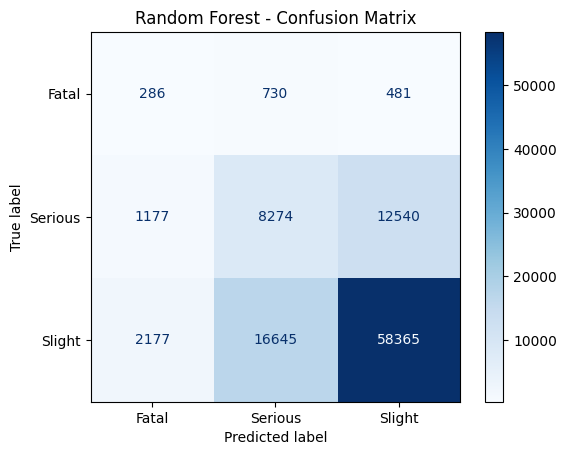

In [5]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Fatal','Serious','Slight'],
    cmap='Blues'
)
plt.title('Random Forest - Confusion Matrix')
plt.savefig('../Output/RF_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
np.save('../Data/y_pred_rf.npy', y_pred_rf)

#### Random Forest Results Summary
- Random Forest uses 100 decision trees voting together
- n_jobs=-1 uses all CPU cores for faster training
- class_weight='balanced' handles the 83/15/2 imbalance
- Compare Fatal F1 score against Logistic Regression baseline
- Higher F1 for Fatal means Random Forest captures complex 
  non-linear patterns that Logistic Regression cannot